# Distillation on synthetic traces — reasoning evals

Plots `summary_reasoning_evals.json` results for the
`distillation_on_synthetic_traces` group, one graph per model.

Each curve is one experiment, showing accuracy across training epochs.
Epoch 0 is the base model evaluated with chain-of-thought
(`base_model/<model>_cot/...`), prepended to every curve and also drawn as a
dashed reference line. Experiments whose training has not finished (no
`summary_reasoning_evals.json`) are skipped automatically, and experiments /
models / datasets are discovered from the directory tree, so re-running picks
up newly finished runs. To analyze another group, copy this notebook and change
`GROUP_NAME`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_on_synthetic_traces"
SUMMARY_FILENAME = "summary_reasoning_evals.json"
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"  # use the *_cot base_model folders for epoch 0
METRIC = "accuracy"
SAVE = True  # also write PNGs under artifacts/<group>/<dataset>/plots/


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
GROUP_DIR = ARTIFACTS / GROUP_NAME
GROUP_DIR

PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_on_synthetic_traces')

In [2]:
def load_curves(dataset_dir: Path) -> dict:
    """model -> experiment -> eval_key -> sorted [(epoch, metric)].

    Skips the base_model folder and any model dir without a finished summary.
    """
    data: dict = {}
    for exp_dir in sorted(dataset_dir.iterdir()):
        if not exp_dir.is_dir() or exp_dir.name == BASE_EXPERIMENT:
            continue
        for model_dir in sorted(exp_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            summary = model_dir / SUMMARY_FILENAME
            if not summary.is_file():
                continue  # training not finished yet
            content = json.loads(summary.read_text())
            for eval_key, records in content.items():
                points = sorted(
                    (r["epoch"], r[METRIC])
                    for r in records
                    if r.get("epoch") is not None and r.get(METRIC) is not None
                )
                data.setdefault(model_dir.name, {}).setdefault(exp_dir.name, {})[eval_key] = points
    return data


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> epoch-0 accuracy from the *_cot base_model folder."""
    out: dict = {}
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    if base_dir.is_dir():
        for results in sorted(base_dir.glob("*/results.json")):
            out[results.parent.name] = json.loads(results.read_text())[METRIC]
    return out

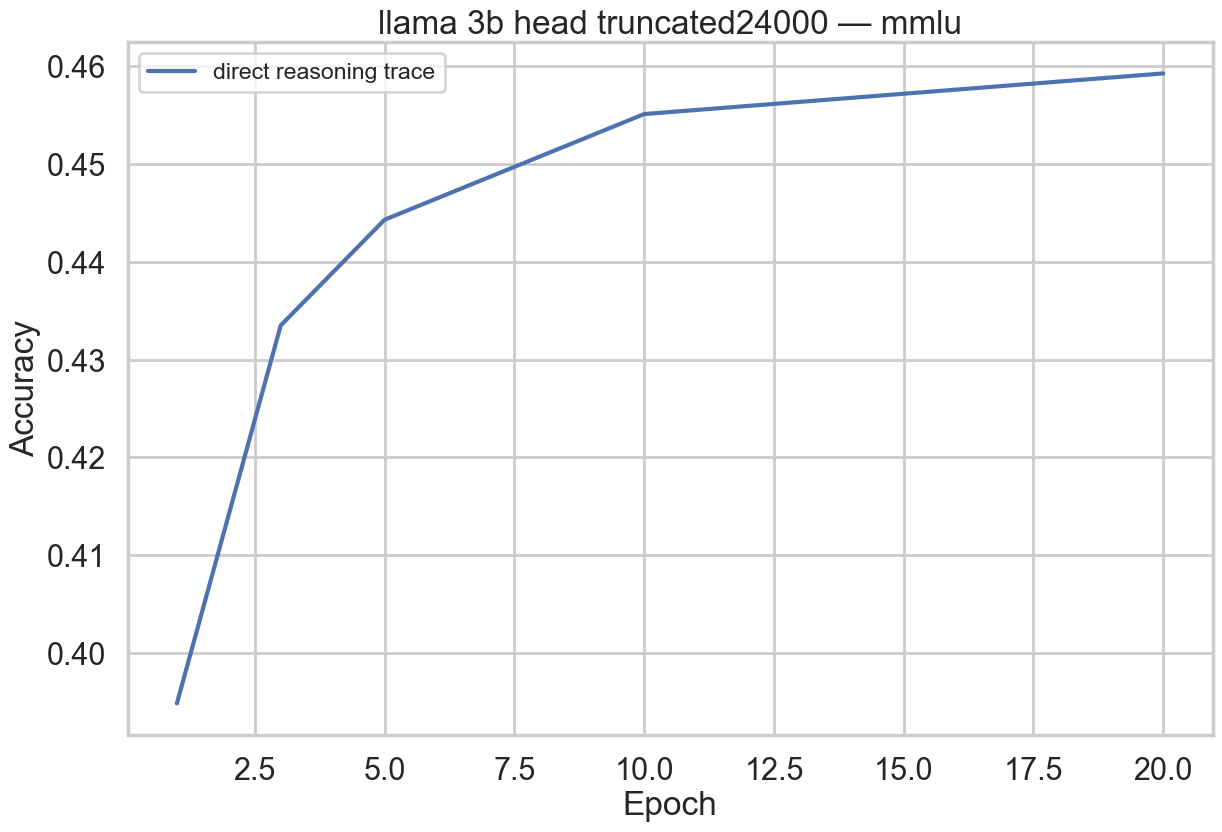

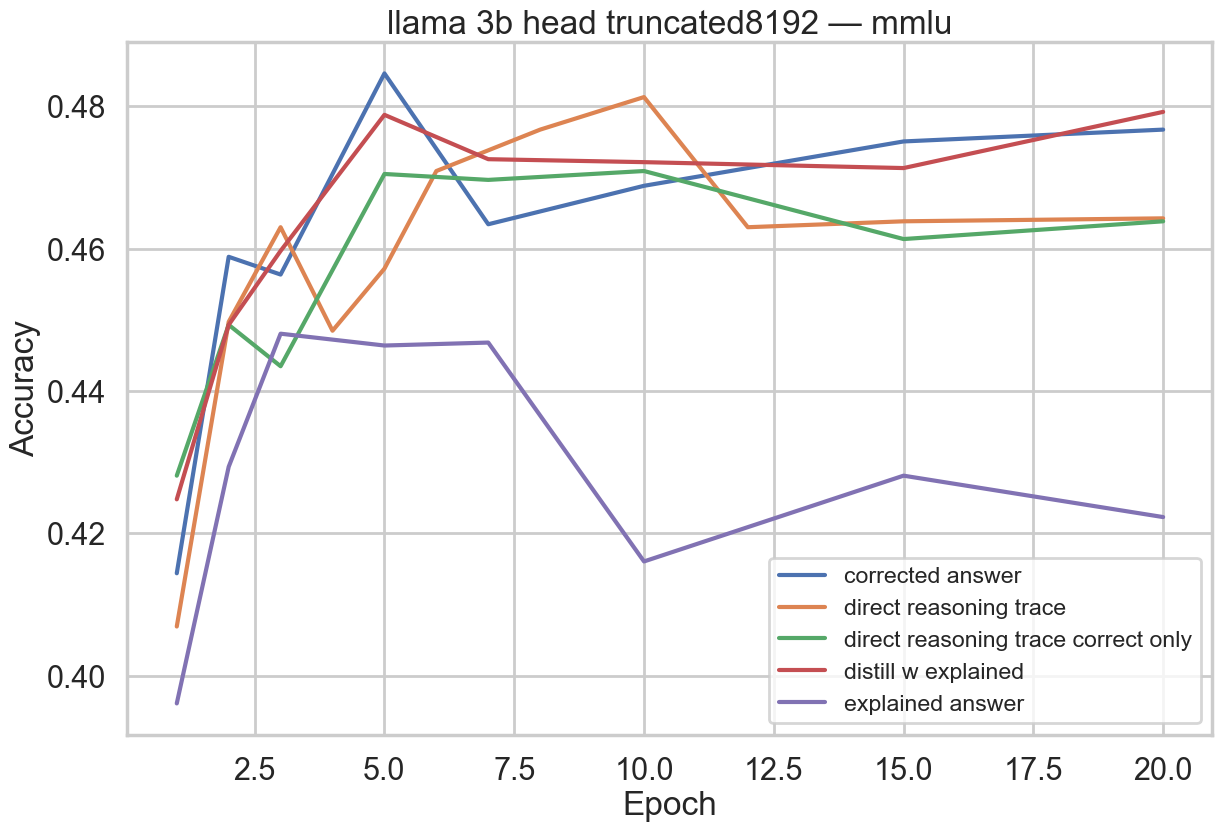

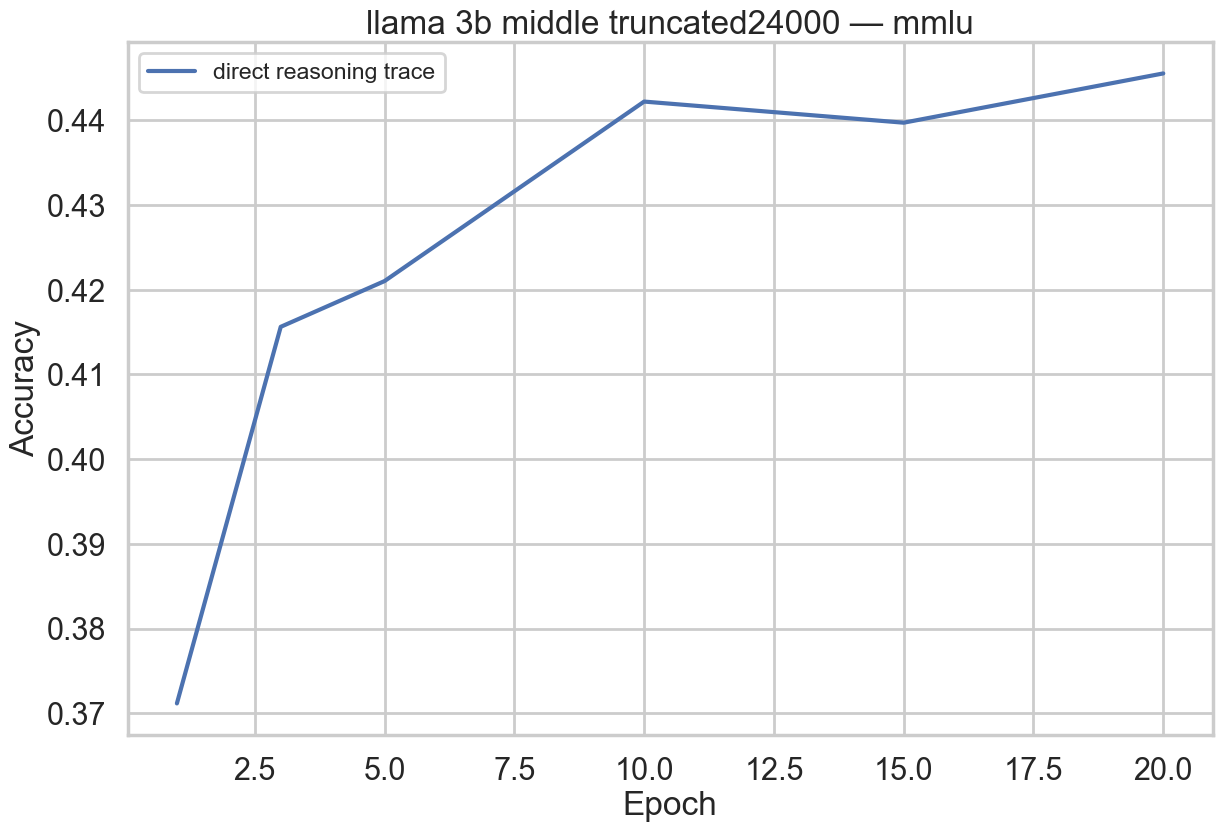

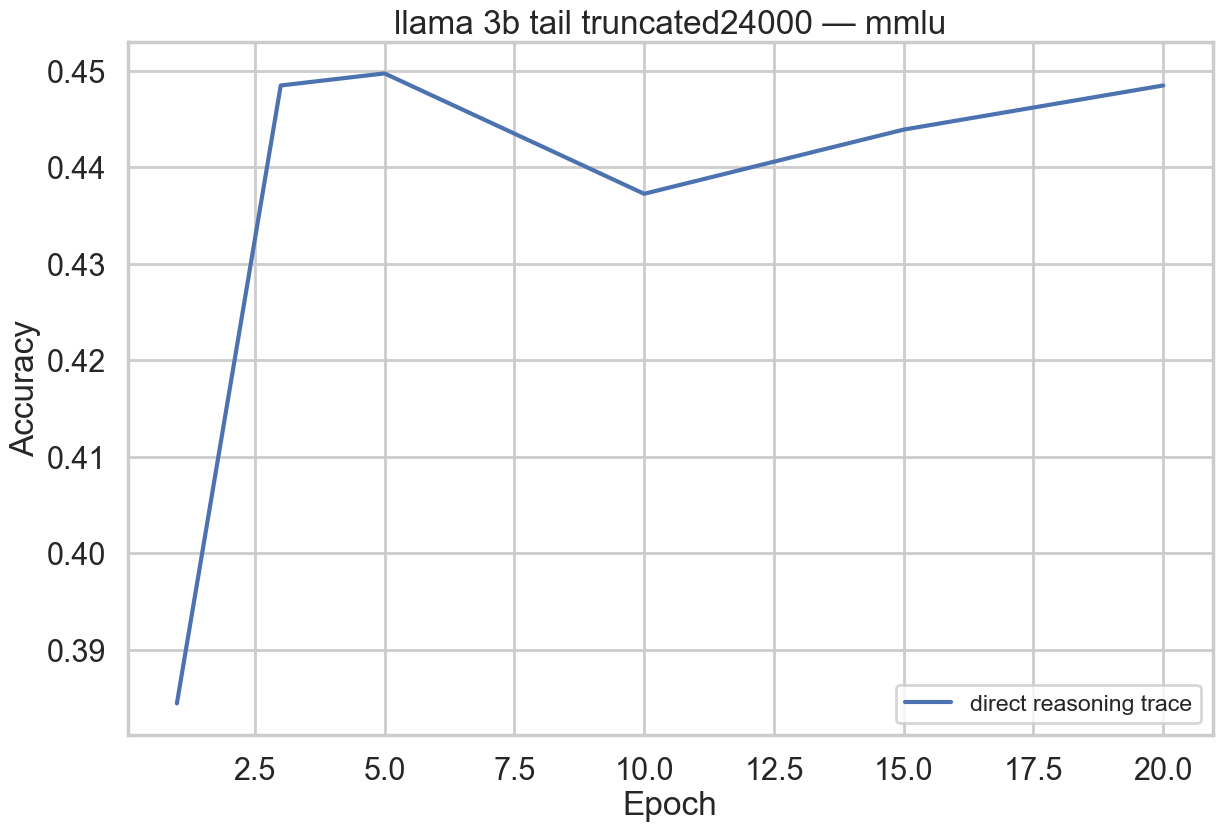

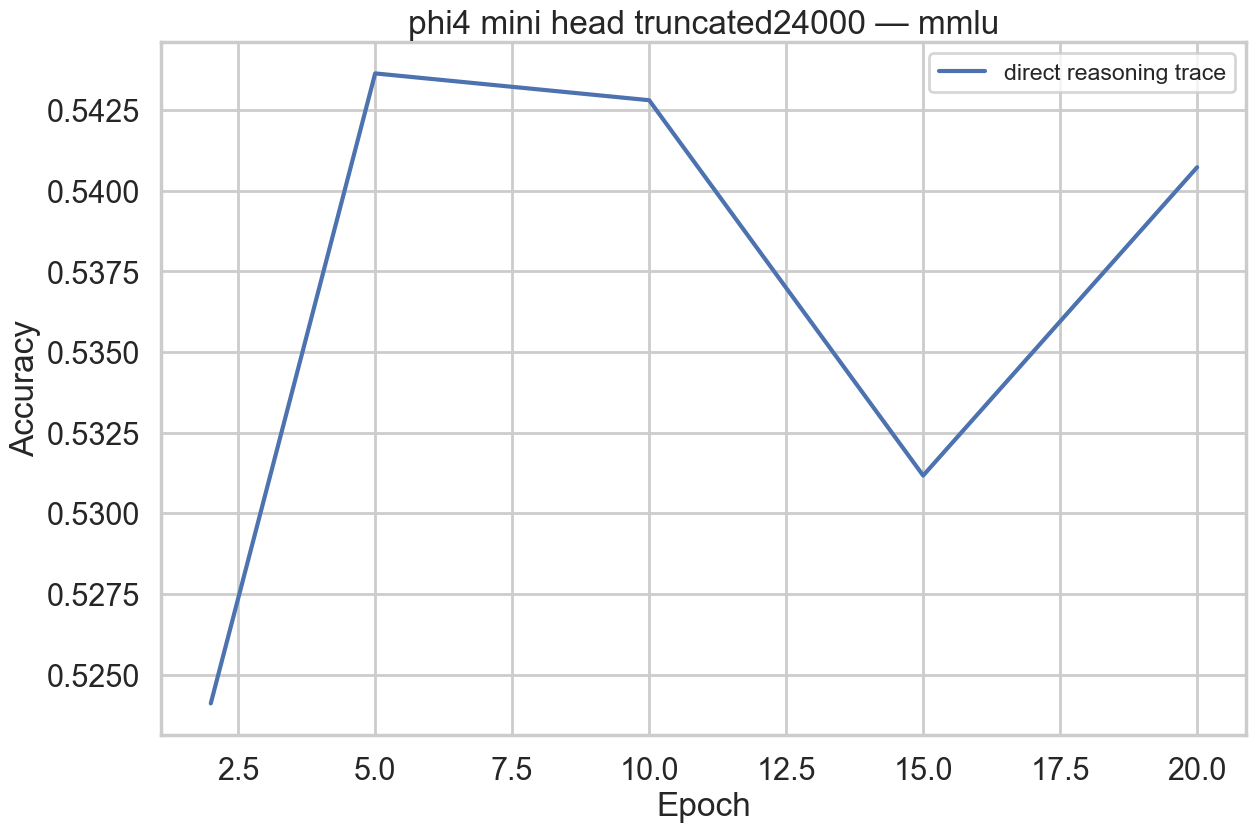

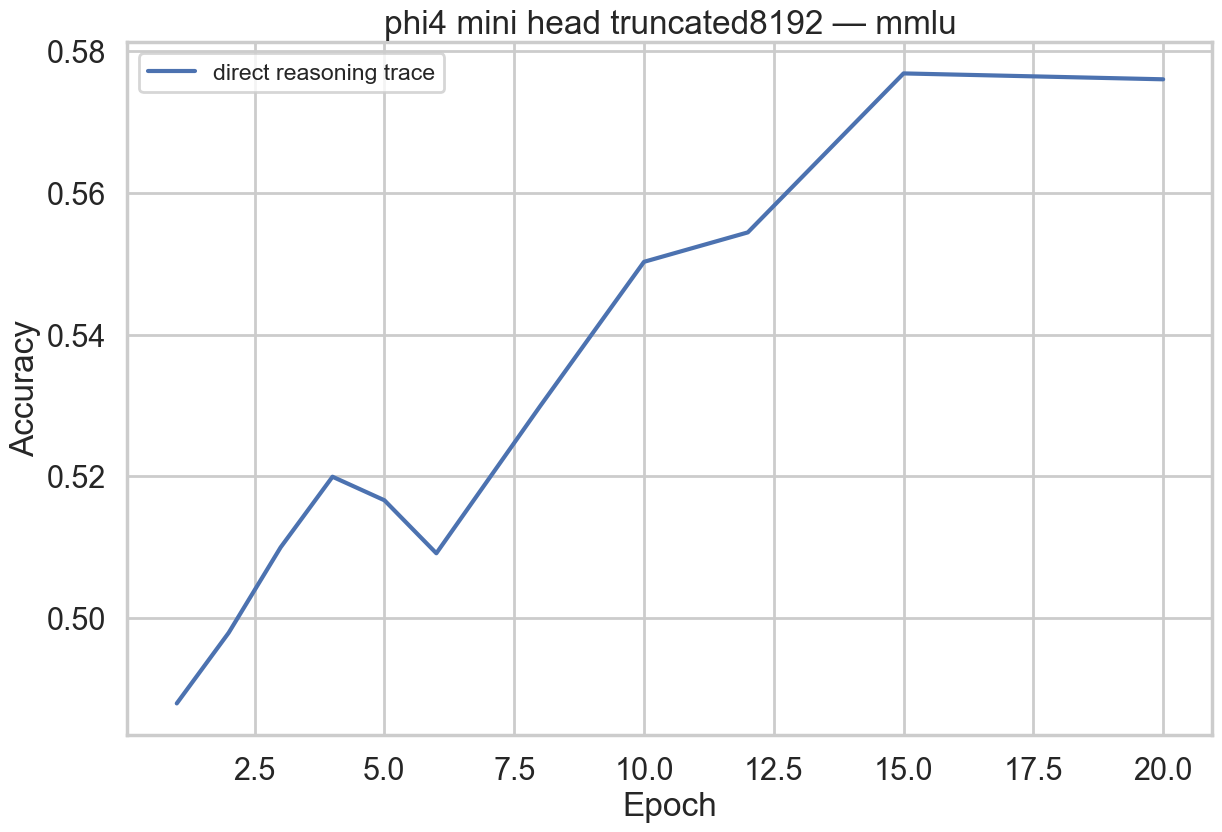

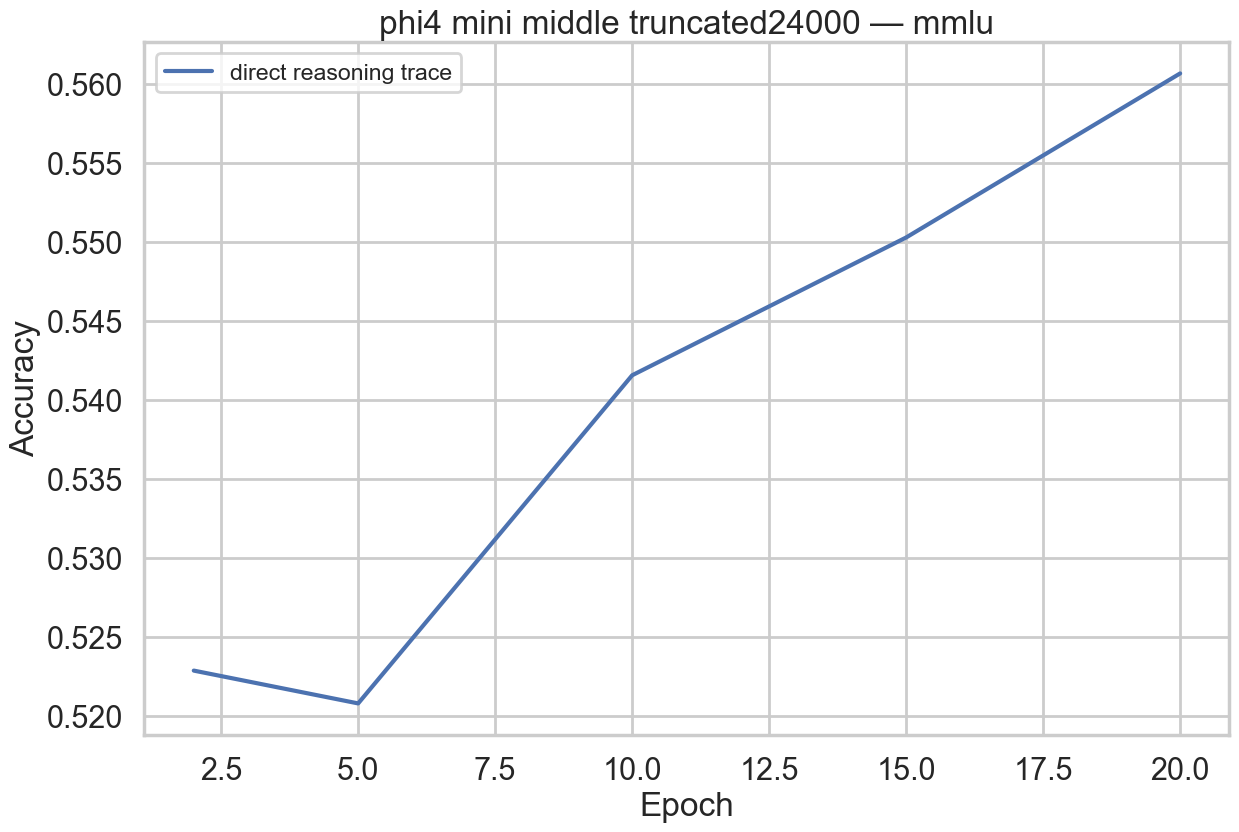

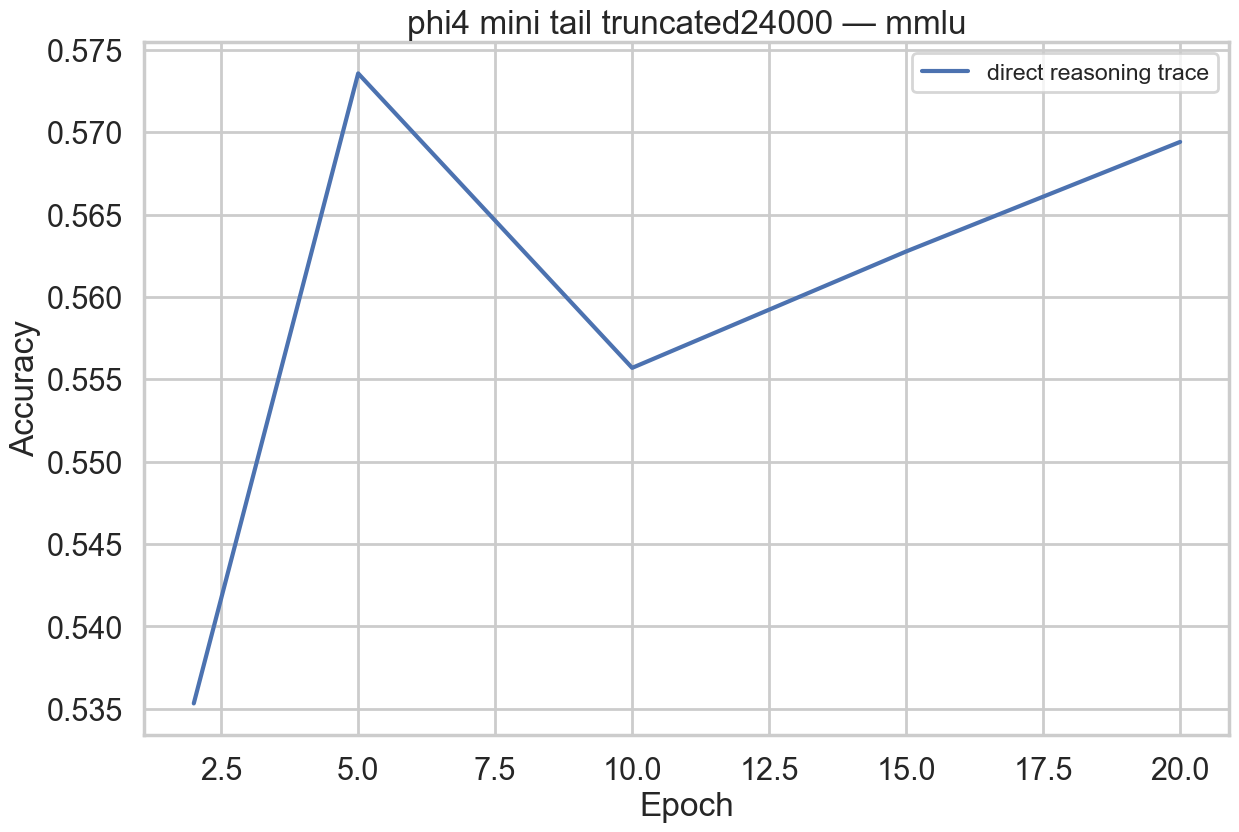

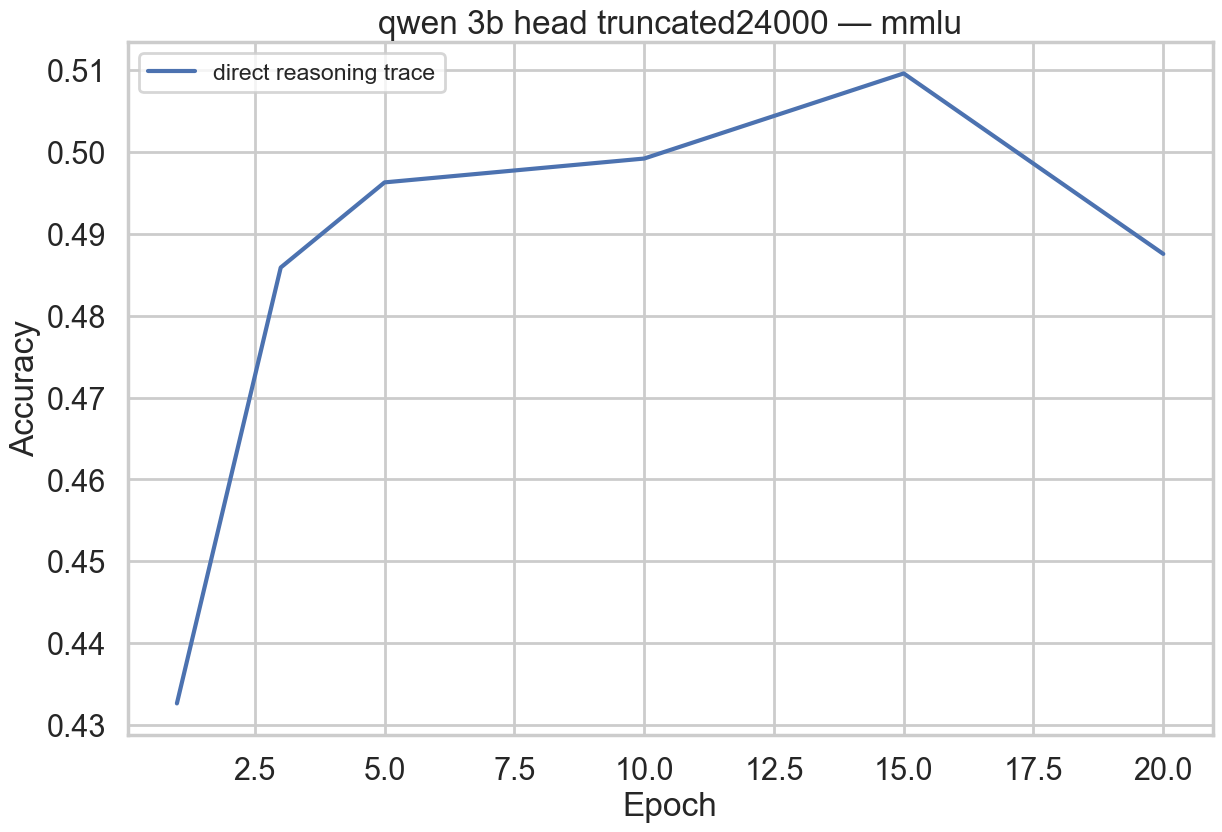

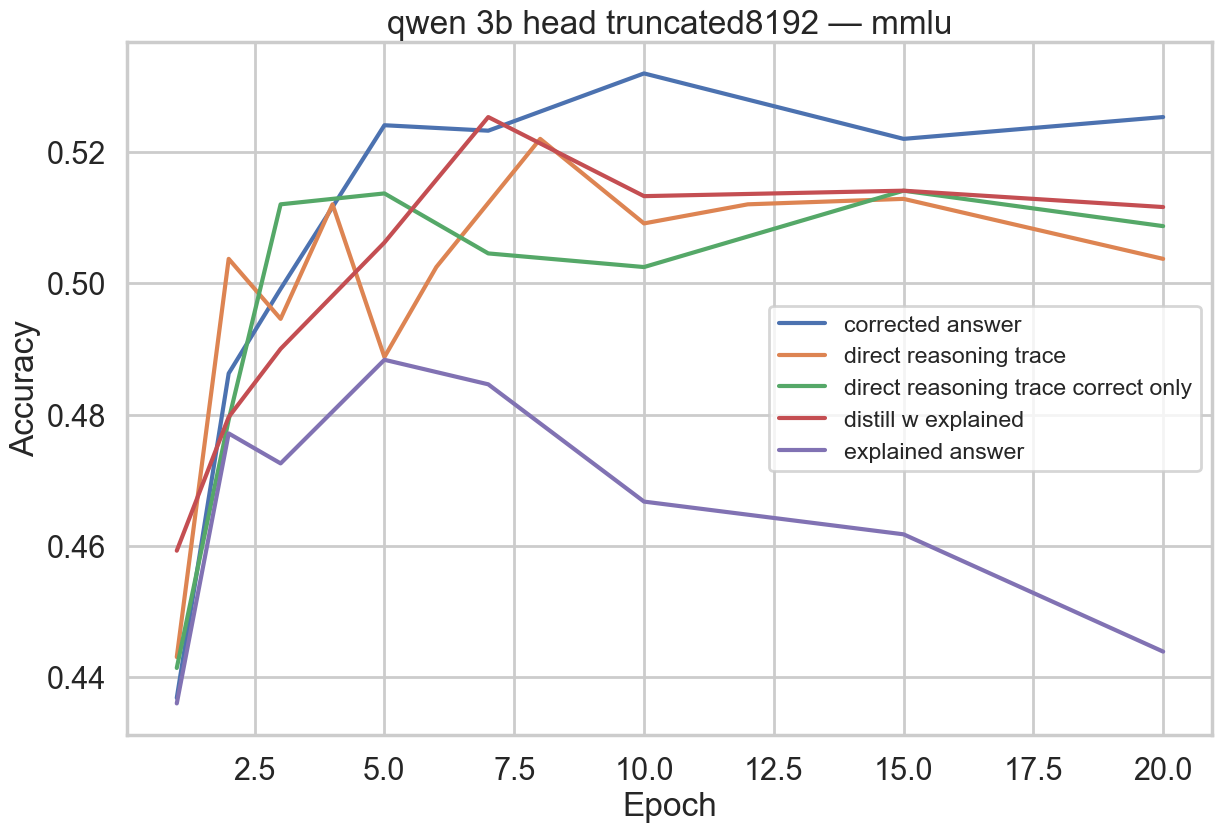

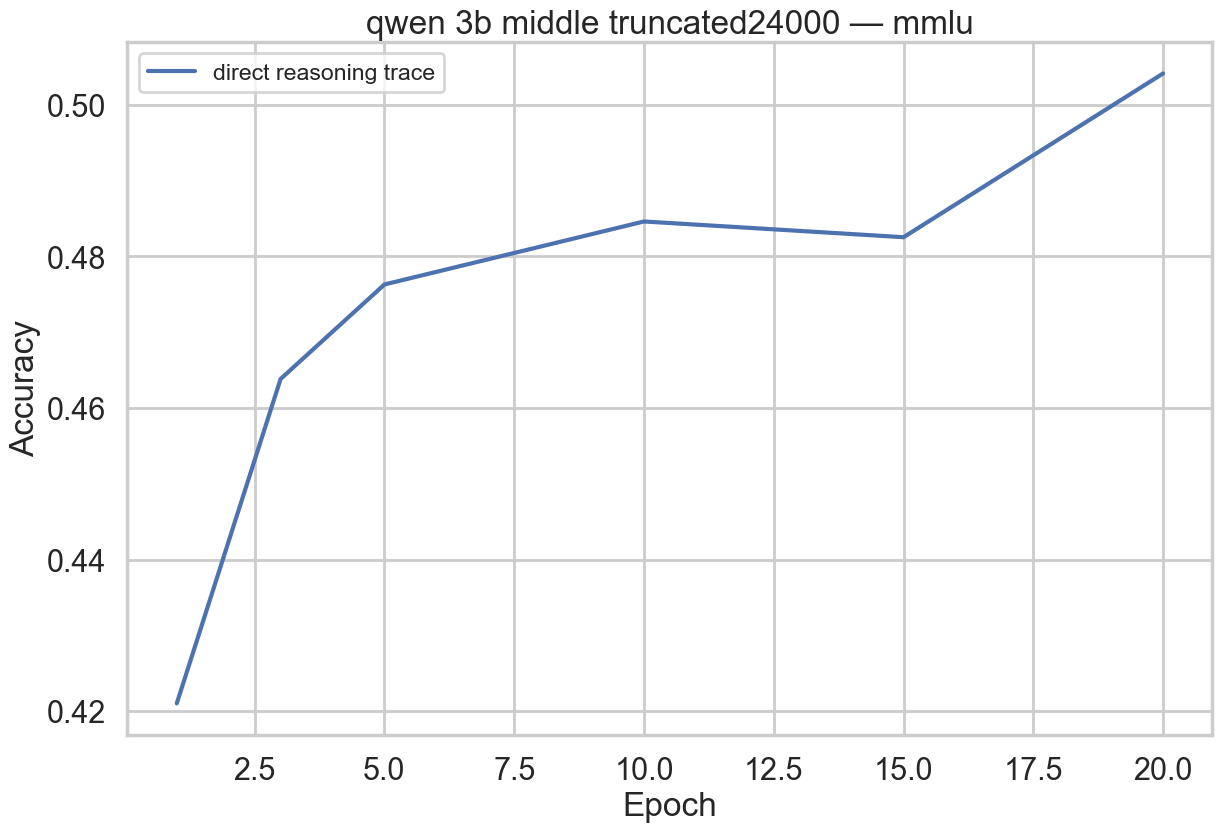

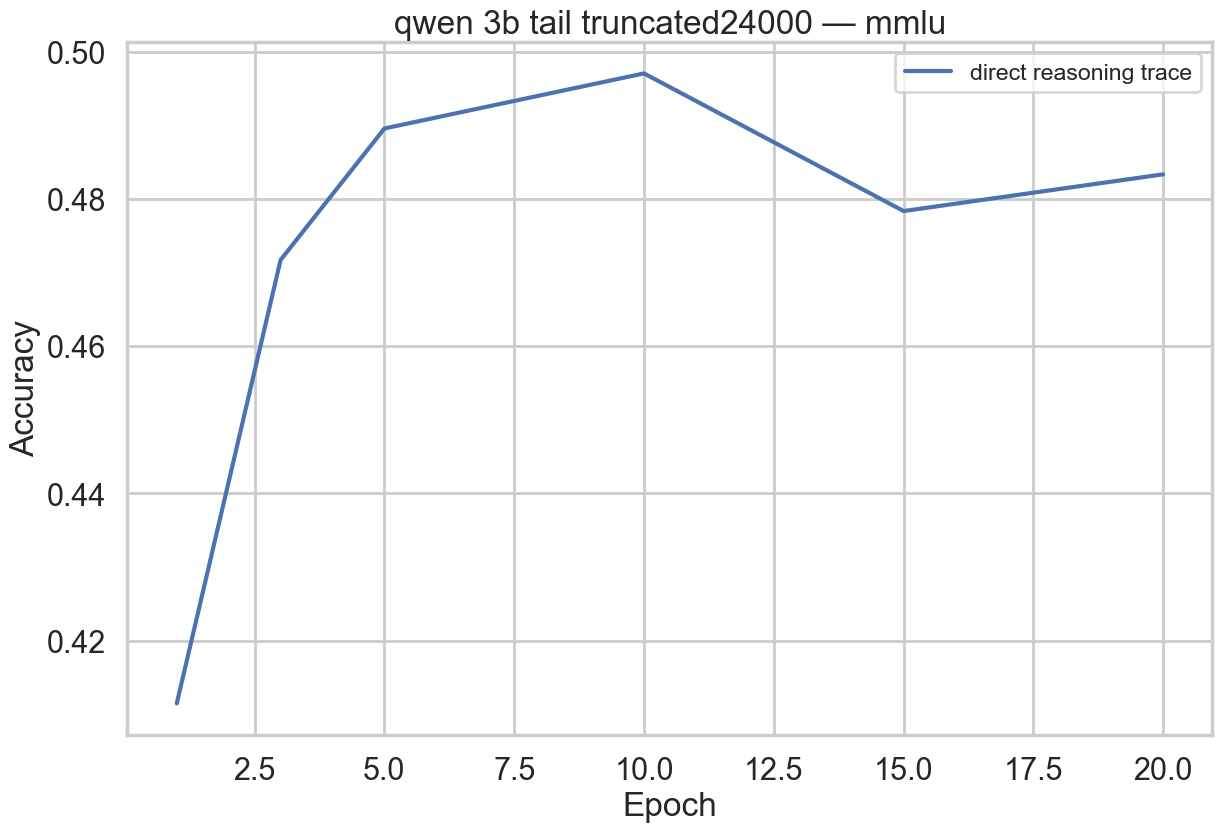

In [3]:
datasets = sorted(p.name for p in GROUP_DIR.iterdir() if p.is_dir())

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    curves = load_curves(dataset_dir)

    for model in sorted(curves):
        base = load_base(dataset_dir, model)
        eval_keys = {key for exp in curves[model].values() for key in exp}
        multi = len(eval_keys) > 1  # disambiguate labels only if needed

        fig, ax = plt.subplots(figsize=(14, 9))

        for experiment in sorted(curves[model]):
            for eval_key, points in curves[model][experiment].items():
                xs = [e for e, _ in points]
                ys = [v for _, v in points]
                if eval_key in base:  # anchor every curve at the epoch-0 base
                    xs = [0.0] + xs
                    ys = [base[eval_key]] + ys
                label = experiment.replace("_", " ")
                if multi:
                    label = f"{label} [{eval_key}]"
                ax.plot(xs, ys, label=label)

        for eval_key, acc in base.items():  # base reference line(s)
            ref_label = "base model (CoT)" + (f" [{eval_key}]" if multi else "")
            ax.axhline(acc, ls="--", color="gray", alpha=0.7, label=ref_label)

        ax.set_title(f"{model.replace('_', ' ')} — {dataset}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(METRIC.capitalize())
        ax.legend(fontsize="x-small", loc="best")

        if SAVE:
            plots_dir = dataset_dir / "plots"
            plots_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                plots_dir / f"{model}_reasoning_evals.png",
                bbox_inches="tight",
                dpi=150,
            )

        plt.show()

## Head-truncated, aggregated by model (`direct_reasoning_trace` only)

The graphs above are one per model *variant* (e.g. `qwen_3b_head_truncated8192`
and `qwen_3b_head_truncated24000` are separate figures). Here we restrict to the
`direct_reasoning_trace` subgroup and the **head** truncation mode, and aggregate
by base model: one figure per base model.

Each figure also breaks out the **evaluation cap** (`max_thinking_tokens` at eval
time), parsed from the summary filename — bare `summary_reasoning_evals.json` is
the default cap **8192**, and `summary_reasoning_evals_cap<N>.json` is cap `N`. So
every line is a `(truncation size, cap)` pair: **each pair gets its own colour**
(from the `tab10` palette, so all lines are distinguishable) and **line style
additionally groups by truncation size**; the size and cap are also spelled out in
the legend. Every truncation size evaluated at any cap is included — so the
3072-truncation runs show up even though they were never evaluated at the default
8192 cap (an 8192 budget on a 3072-token trace is a no-op); those lines therefore
have no cap-8192 point and no epoch-0 base anchor. The base-model CoT accuracy is
drawn as a dashed reference line (default cap only), and variants without a
finished summary are skipped.

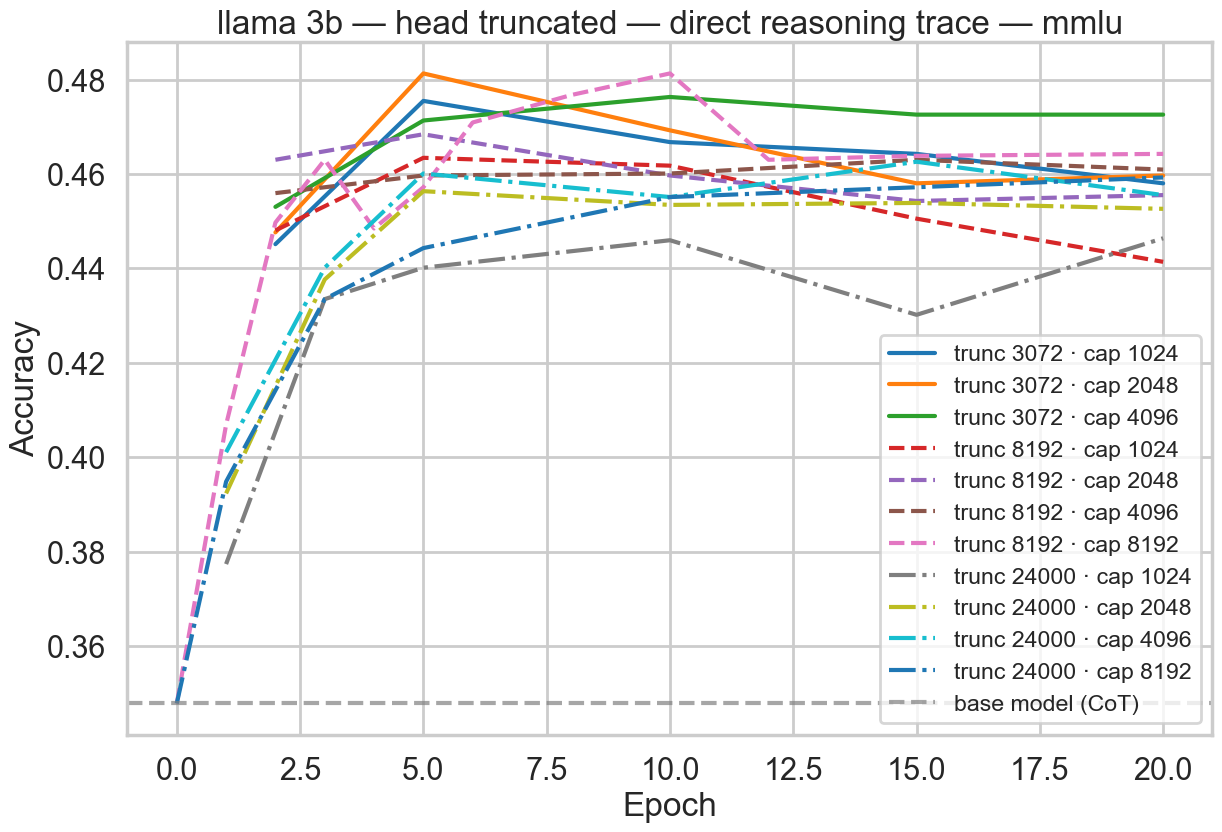

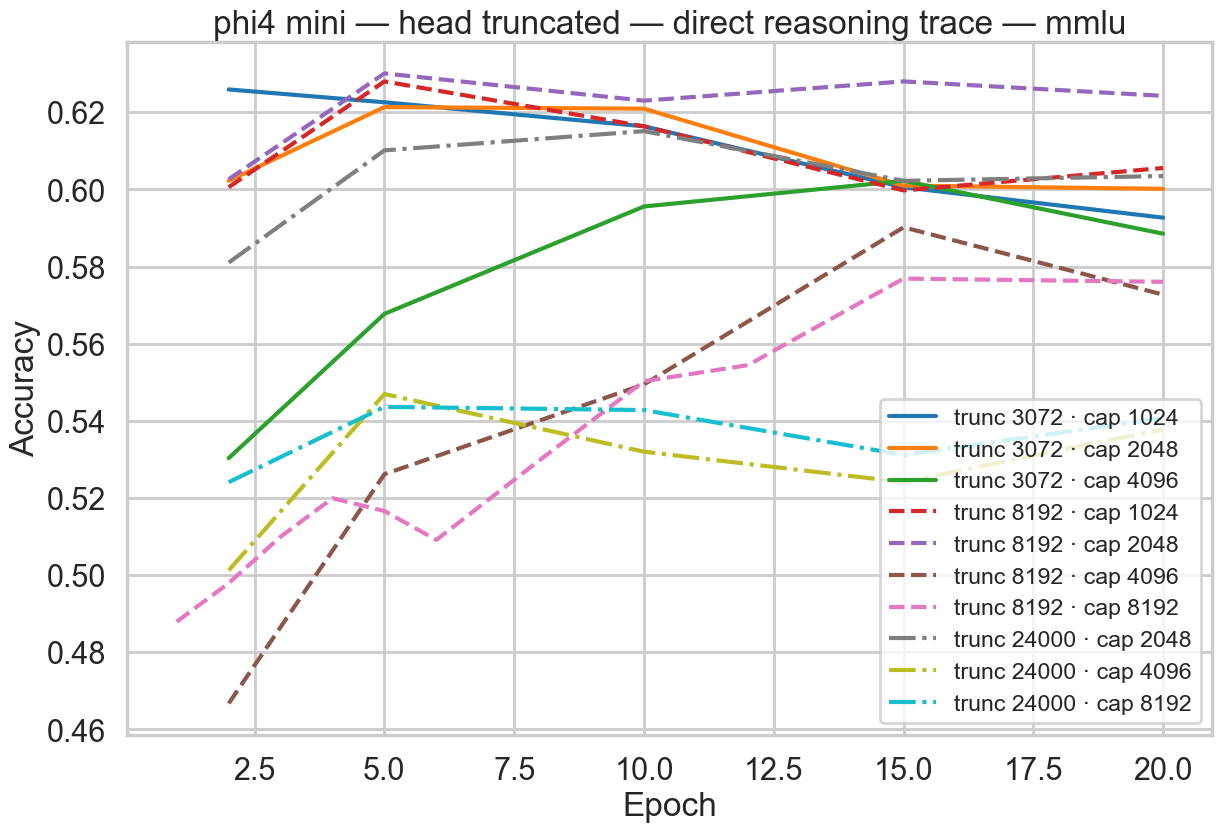

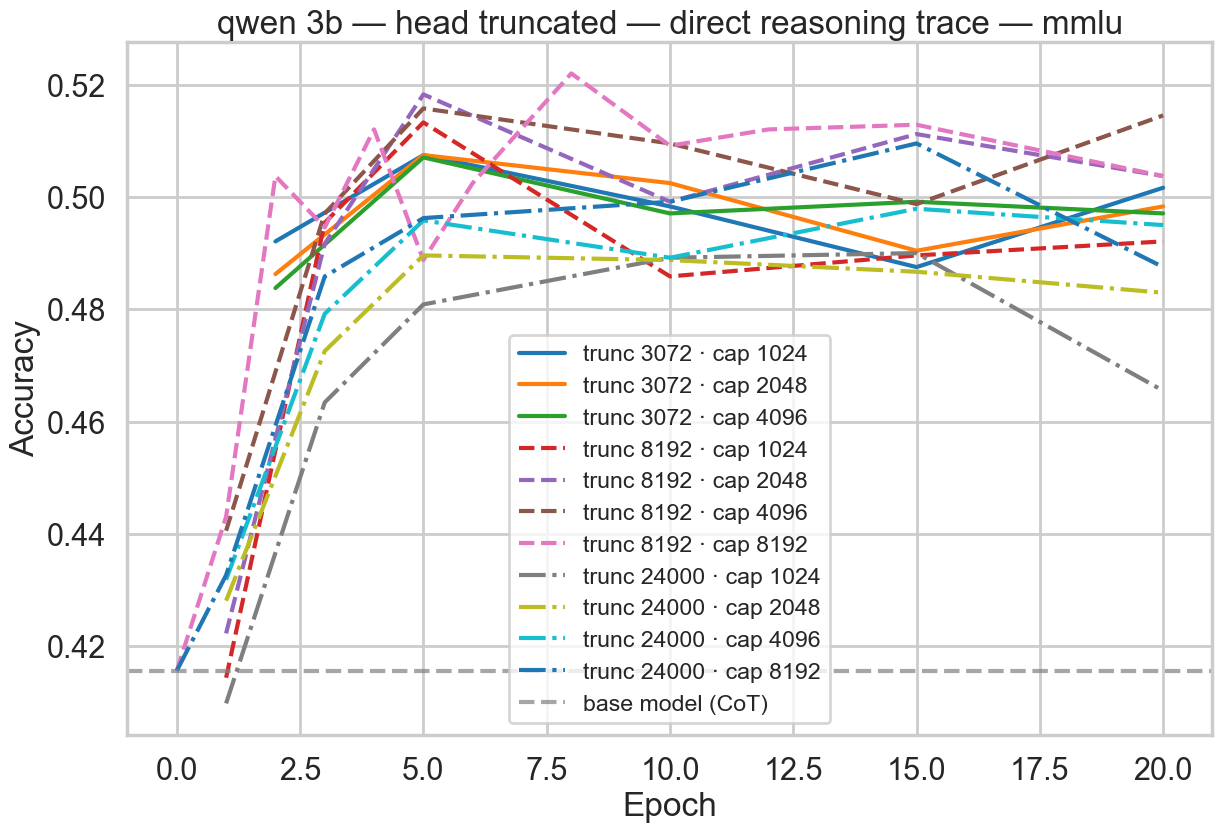

In [4]:
import re

SUBGROUP = "direct_reasoning_trace"
TRUNC_MODE = "head"
DEFAULT_CAP = 8192  # bare summary_reasoning_evals.json == eval cap 8192
VARIANT_RE = re.compile(r"^(?P<model>.+)_(?P<mode>head|middle|tail)_truncated(?P<size>\d+)$")
SUMMARY_GLOB = "summary_reasoning_evals*.json"
CAP_RE = re.compile(r"summary_reasoning_evals(?:_cap(\d+))?\.json$")


def load_head_curves_by_model(dataset_dir: Path) -> dict:
    """base_model -> size -> cap -> (eval_key, sorted [(epoch, metric)]).

    Only the `direct_reasoning_trace` subgroup and the head truncation mode. The
    eval cap is parsed from the summary filename (bare file == DEFAULT_CAP). A
    (model, size) variant is kept if it was evaluated at any cap, so variants that
    only ran at caps below the default (e.g. the 3072-truncation runs, where an
    8192 budget is a no-op) are included too -- those simply have no default-cap
    line and no epoch-0 base anchor.
    """
    data: dict = {}
    subgroup_dir = dataset_dir / SUBGROUP
    if not subgroup_dir.is_dir():
        return data
    for variant_dir in sorted(subgroup_dir.iterdir()):
        if not variant_dir.is_dir():
            continue
        m = VARIANT_RE.match(variant_dir.name)
        if not m or m.group("mode") != TRUNC_MODE:
            continue
        per_cap: dict = {}
        for summary in sorted(variant_dir.glob(SUMMARY_GLOB)):
            cm = CAP_RE.search(summary.name)
            if not cm:
                continue
            cap = int(cm.group(1)) if cm.group(1) else DEFAULT_CAP
            content = json.loads(summary.read_text())
            eval_key = next(iter(content))  # single eval-key per cap file
            points = sorted(
                (r["epoch"], r[METRIC])
                for r in content[eval_key]
                if r.get("epoch") is not None and r.get(METRIC) is not None
            )
            if points:
                per_cap[cap] = (eval_key, points)
        if per_cap:  # keep any variant evaluated at >= 1 cap
            data.setdefault(m.group("model"), {})[int(m.group("size"))] = dict(
                sorted(per_cap.items())
            )
    return data


LINESTYLES = ["-", "--", "-.", ":"]
CMAP = plt.get_cmap("tab10")  # distinct colour per (size, cap) line

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    by_model = load_head_curves_by_model(dataset_dir)

    for model in sorted(by_model):
        base = load_base(dataset_dir, model)
        sizes = sorted(by_model[model])
        size_ls = {size: LINESTYLES[i % len(LINESTYLES)] for i, size in enumerate(sizes)}

        fig, ax = plt.subplots(figsize=(14, 9))

        color_i = 0  # linestyle = truncation size, distinct colour per line
        for size in sizes:
            for cap, (eval_key, points) in by_model[model][size].items():
                xs = [e for e, _ in points]
                ys = [v for _, v in points]
                if eval_key in base:  # only the default-cap curve anchors at epoch 0
                    xs = [0.0] + xs
                    ys = [base[eval_key]] + ys
                ax.plot(
                    xs,
                    ys,
                    color=CMAP(color_i % CMAP.N),
                    ls=size_ls[size],
                    label=f"trunc {size} · cap {cap}",
                )
                color_i += 1

        for eval_key, acc in base.items():  # default-cap base reference line
            ax.axhline(acc, ls="--", color="gray", alpha=0.7, label="base model (CoT)")

        ax.set_title(
            f"{model.replace('_', ' ')} — head truncated — "
            f"{SUBGROUP.replace('_', ' ')} — {dataset}"
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel(METRIC.capitalize())
        ax.legend(fontsize="x-small", loc="best")

        if SAVE:
            plots_dir = dataset_dir / "plots"
            plots_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                plots_dir / f"{model}_head_truncated_by_model.png",
                bbox_inches="tight",
                dpi=150,
            )

        plt.show()